In [146]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

In [147]:
df = pd.read_csv('Heracleum mantegazzianum.csv', engine='pyarrow')
df_weather = pd.read_csv('knmi_weather_cache.csv', engine='pyarrow')
df_habitats = pd.read_csv('habitats_cbs_2022.csv', engine='pyarrow')

#df.sample(10)
#df_weather.sample(10)
#df_habitats.sample(10)

In [148]:
df.info(verbose=True)
df.describe()

df_weather.info(verbose=True)
df_weather.describe()

df_habitats.info(verbose=True)
df_habitats.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Heracleum mantegazzianum   str    
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 586.9+ MB
<class 'pandas.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              5844 non-null   object 
 1   mean_temp_c       5844 non-null   float64
 2   max_temp_c        5844 non-null   float64
 3   min_temp_c        5844 non-null   float64
 4   precipitation_mm  5844 non-null   float64
dtypes: float64(4), object(1)
memory usage: 228.4+ KB
<class 'pandas.DataFrame'>


,decimalLongitude,decimalLatitude,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000
mean,5.510624,52.242336,9.571166,2.600712,1.510309,1.816148,1.716892,0.405040,1.461374,0.414471
std,0.890036,0.664786,5.303015,3.053375,4.443380,3.040838,2.366745,2.245601,3.402881,2.089655
min,3.350000,50.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.850000,51.700000,5.394250,0.780050,0.000000,0.153250,0.735300,0.000000,0.102800,0.000000
50%,5.650000,52.200000,10.623900,1.584300,0.000000,0.735100,1.213500,0.000000,0.318300,0.019300
75%,6.150000,52.800000,13.883000,3.391350,0.000000,2.123850,2.042500,0.027000,1.096200,0.157850
max,7.200000,53.500000,29.522800,29.835000,28.982000,28.075200,29.906000,29.408500,29.863600,28.847500


In [149]:
#df[df.duplicated()] true

From the initial data description, it is visible that not all columns have the correct data types. The *eventDate* column should be formatted in **datetime** instead of in **string**, the *total_observations* column is formatted as **float**, and while that's usable, it should be of the **integer** type instead, and finally the *Heracleum mantegazzianum* column is in **string**, while that should be an **integer** column as well.

From the above duplicate check, it is also visible that there are **no** duplicates. (Ruben)

In [150]:
for col in df.columns:
    uniques = df[col].unique()[:10].tolist()
    print(f"{col}: {uniques}...")
print(df.head(5).to_string())

decimalLatitude: [50.75, 50.8, 50.85, 50.9, 50.95, 51.0, 51.05, 51.1, 51.15, 51.2]...
decimalLongitude: [5.65, 5.7, 5.75, 5.8, 5.85, 5.9, 5.95, 6.0, 5.6, 6.05]...
eventDate: [datetime.date(2010, 1, 1), datetime.date(2010, 1, 2), datetime.date(2010, 1, 3), datetime.date(2010, 1, 4), datetime.date(2010, 1, 5), datetime.date(2010, 1, 6), datetime.date(2010, 1, 7), datetime.date(2010, 1, 8), datetime.date(2010, 1, 9), datetime.date(2010, 1, 10)]...
total_observations: [0.0, 26.0, 3.0, 1.0, 18.0, 11.0, 6.0, 7.0, 5.0, 12.0]...
speciesgroup_observations: [0, 1, 15, 11, 13, 3, 42, 46, 9, 7]...
Heracleum mantegazzianum: ['0', '2', '1', '3', '5', '4', '6', '7', '8', '10']...
   decimalLatitude  decimalLongitude   eventDate  total_observations  speciesgroup_observations Heracleum mantegazzianum
0            50.75              5.65  2010-01-01                 0.0                          0                        0
1            50.75              5.65  2010-01-02                26.0                

TLDR;
some **NAN** values in total_observations
Heracleum mantegazzianum array has some *unknown* and *-1 negative values* (Mika)

In [151]:
df['total_observations'] = pd.to_numeric(df['total_observations'], errors='coerce')
df['total_observations'] = df['total_observations'].fillna(0).astype(np.int32)
df['speciesgroup_observations'] = df['speciesgroup_observations'].astype(np.int32)
df['decimalLatitude'] = df['decimalLatitude'].astype(np.float32)
df['decimalLongitude'] = df['decimalLongitude'].astype(np.float32)
#print(df['total_observations'].dtype, len(df['total_observations']))
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather['mean_temp_c'] = df_weather['mean_temp_c'].astype(np.float32)
df_weather['max_temp_c'] = df_weather['max_temp_c'].astype(np.float32)
df_weather['min_temp_c'] = df_weather['min_temp_c'].astype(np.float32)
df_weather['precipitation_mm'] = df_weather['precipitation_mm'].astype(np.float32)
#df_weather['']

I observed that the total_observations column was with float values and NaNs. To mitigate this, I converted all NaNs to 0 and all values from float to int. (Marcell)

In [152]:
cat_series = df['Heracleum mantegazzianum'].astype('category')
unique_cats = pd.to_numeric(cat_series.cat.categories, errors='coerce').to_numpy()
clean_cats = np.where(np.isnan(unique_cats) | (unique_cats < 0), 0, unique_cats).astype(np.int8)
df['Heracleum mantegazzianum'] = clean_cats[cat_series.cat.codes]

The Heracleum mantegazzianum column was originally in a string format. All unknown / NaN values were converted to 0 and all others including the new 0s were converted to integers. Furthermore, all values below 0 were raised to 0 as there was at least 1 instance where the row value was below 0 (-1). (Marcell)

In [153]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
#df['eventDate'].sample(10)

In [154]:
df_merged = df.merge(df_weather, left_on='eventDate', right_on='date', how='left')
df_merged = df_merged.drop(columns='date')

# df_merged.info(verbose=True)

The *weather* and *observation* datasets were merged here. (Ruben)

The *eventDate* column was with *string* values instead of *datetime* values. To correct this, I changed the eventDate column to be of the ***datetime data type***. (Ruben)

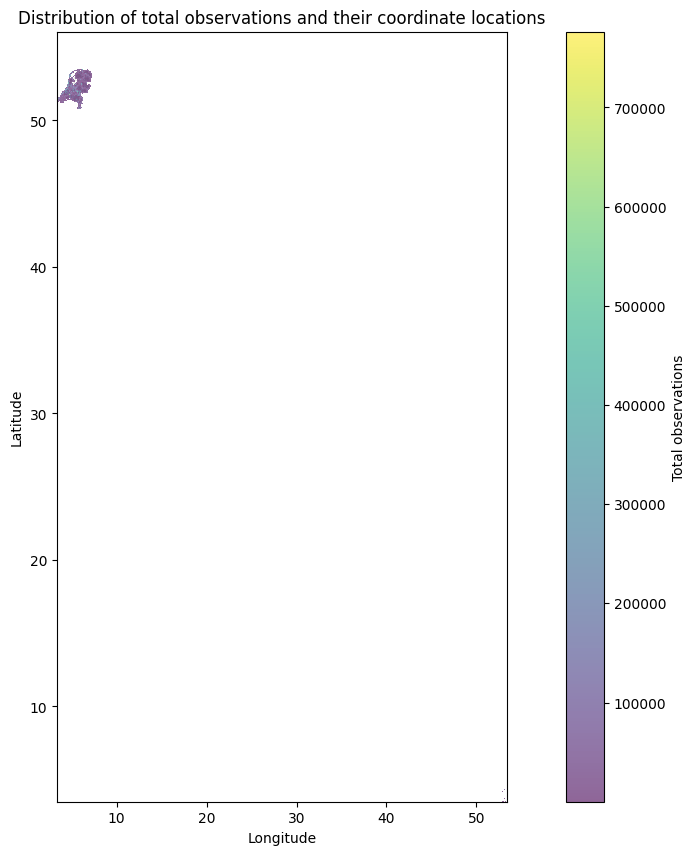

In [155]:
nl_layer = gpd.read_file("gadm41_NLD.gpkg", layer="ADM_ADM_1")
def show_distribution_map(df_map, nl):
    fig, ax = plt.subplots(figsize=(15, 10))
    nl.plot(ax=ax, color='lightgray', edgecolor='white')

    bin_w = 0.05
    x_bins = np.arange(df_map['decimalLongitude'].min(), df_map['decimalLongitude'].max() + bin_w, bin_w)
    y_bins = np.arange(df_map['decimalLatitude'].min(), df_map['decimalLatitude'].max() + bin_w, bin_w)

    heatmap, xedges, yedges = np.histogram2d(
        df_map['decimalLongitude'],
        df_map['decimalLatitude'],
        bins=[x_bins, y_bins],
        weights=df_map['total_observations']
    )

    heatmap = np.where(heatmap == 0, np.nan, heatmap)
    mesh = ax.pcolormesh(
        xedges,
        yedges,
        heatmap.T,
        alpha=0.6,
        cmap='viridis'
    )
    fig.colorbar(mesh, ax=ax, label='Total observations')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Distribution of total observations and their coordinate locations")
    plt.show()

show_distribution_map(df_merged, nl_layer)

I took the latitude and longitude coordinates from the observations, and applied them in a *distplot* to show ***distribution of observations*** by using the *total_observations* column as a weight. This is done to learn where most observations are made. This means we have also learnt that some observations appear to have been made in ***Somalia***. Either that or the coordinates of those observations have been **inverted**. This is something to fix before we move forward.

We can either choose to *invert* these values and fix them, or choose to *remove them. Ideally, we shall do the former.

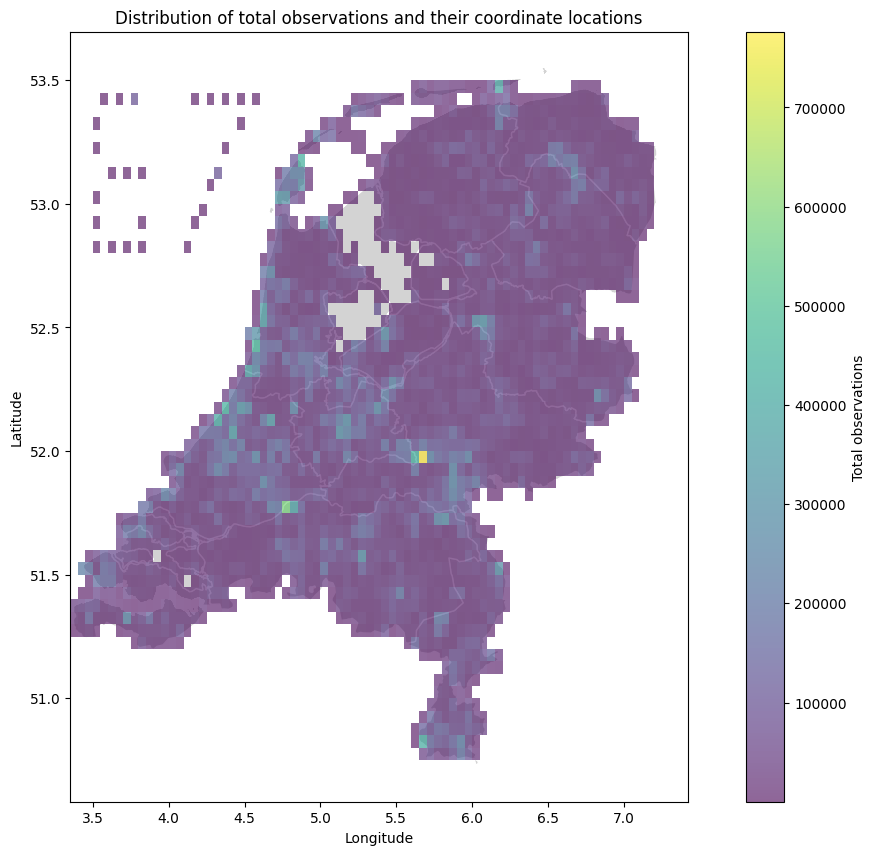

In [156]:
df_nlmap = df_merged[['decimalLatitude','decimalLongitude', 'total_observations']].copy()
mask = ((df_nlmap['decimalLatitude'] < 10) & (df_nlmap['decimalLongitude'] > 40))
df_nlmap.loc[mask, ['decimalLatitude', 'decimalLongitude']] = df_nlmap.loc[mask, ['decimalLongitude', 'decimalLatitude']].values

show_distribution_map(df_nlmap, nl_layer)

I *inverted* the coordinates so they can show up properly on the map. However, now we can see that someone was trying to be funny and added a random 67 to the map. We will need to remove this.

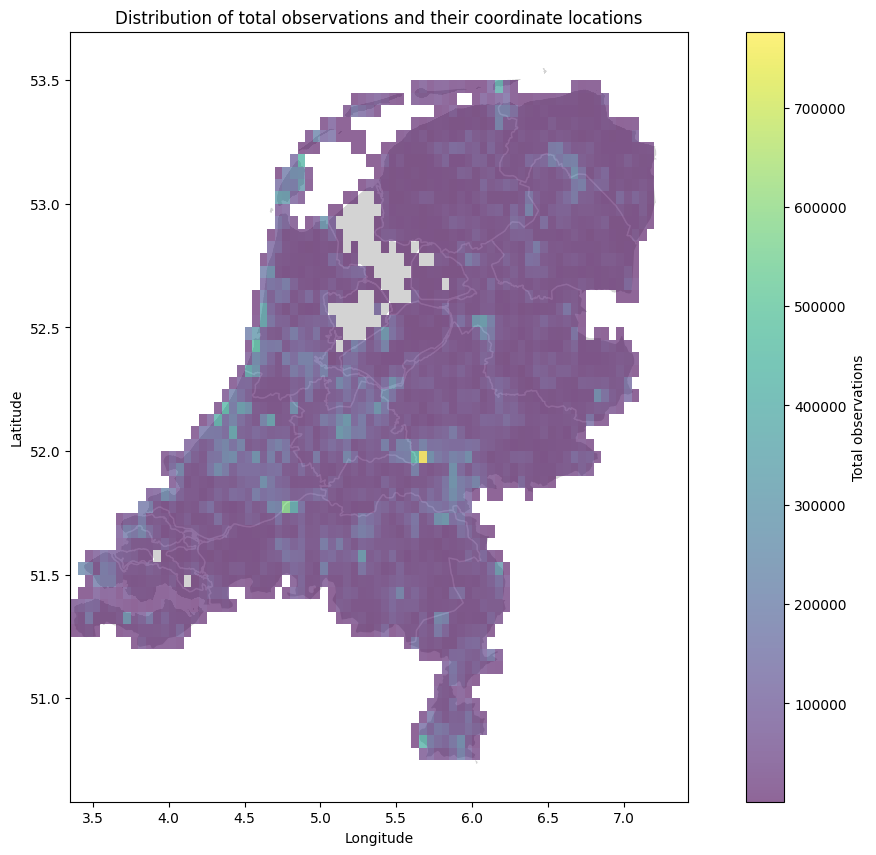

In [157]:
df_merged = df_merged[
    (df_merged['decimalLatitude'].between(50.7, 53.6)) &
    (df_merged['decimalLongitude'].between(3.3, 7.2))]

show_distribution_map(df_merged, nl_layer)

Here the 67 was *removed* from the map.

<Axes: >

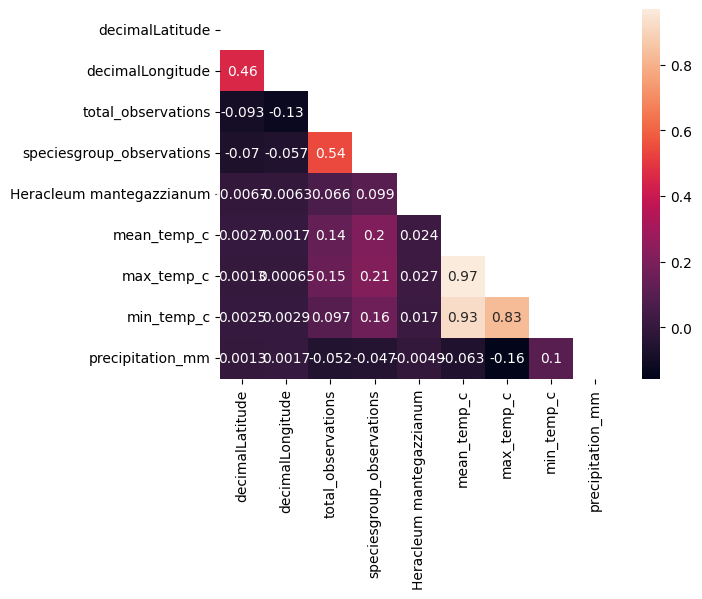

In [158]:
df_corr_sample = df_merged.sample(100000, random_state=42)
df_corr = df_corr_sample.corr(method='spearman', numeric_only=True)
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, annot=True, mask=mask)

Upon creating a quick correlation matrix we can conclude there's some correlation between total_observations and speciesgroup_observations as well as minor correlation between speciesgroup_observation and our target value. There is also high correlation between latitude and longitude. This makes perfect sense.

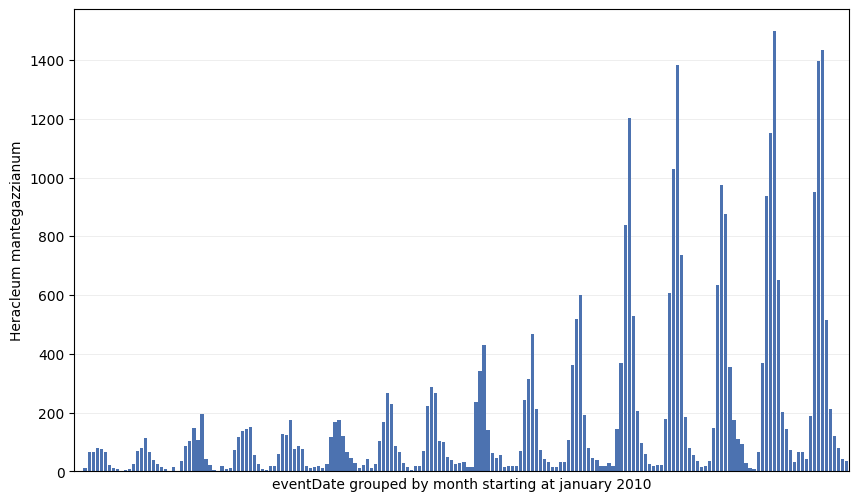

In [159]:
df_months = df_merged.groupby(df_merged['eventDate'].dt.to_period('M'))['Heracleum mantegazzianum'].sum()
fig, ax = plt.subplots(figsize=(10, 6))
df_months.plot(kind='bar', ax=ax, width=0.8, color='#4c72b0', edgecolor='none')

ax.set_xticks([])
ax.set_xlabel("eventDate grouped by month starting at january 2010")
ax.set_ylabel("Heracleum mantegazzianum")
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.set_axisbelow(True)
plt.show()

<Axes: xlabel='eventDate', ylabel='Heracleum mantegazzianum'>

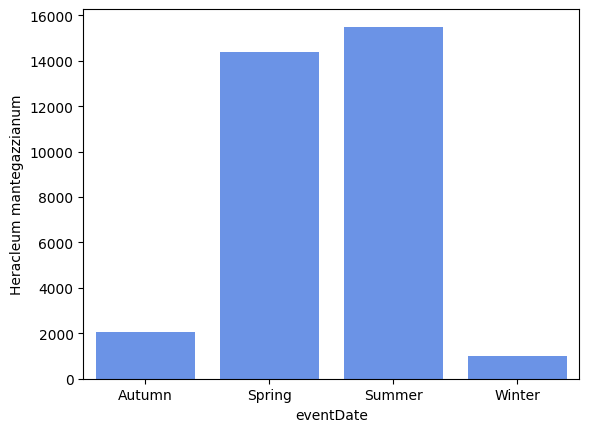

In [160]:
win: str = "Winter"
spr: str = "Spring"
smr: str = "Summer"
aut: str = "Autumn"

season_map = {
    12: win, 1: win, 2: win,
    3: spr, 4: spr, 5: spr,
    6: smr, 7: smr, 8: smr,
    9: aut, 10: aut, 11: aut }

df_months = df_merged[['eventDate', 'Heracleum mantegazzianum']].copy()
df_months['eventDate'] = df_months['eventDate'].dt.month.map(season_map)
df_months = df_months.groupby('eventDate').sum(numeric_only=True)

sns.barplot(data=df_months, x='eventDate', y='Heracleum mantegazzianum')

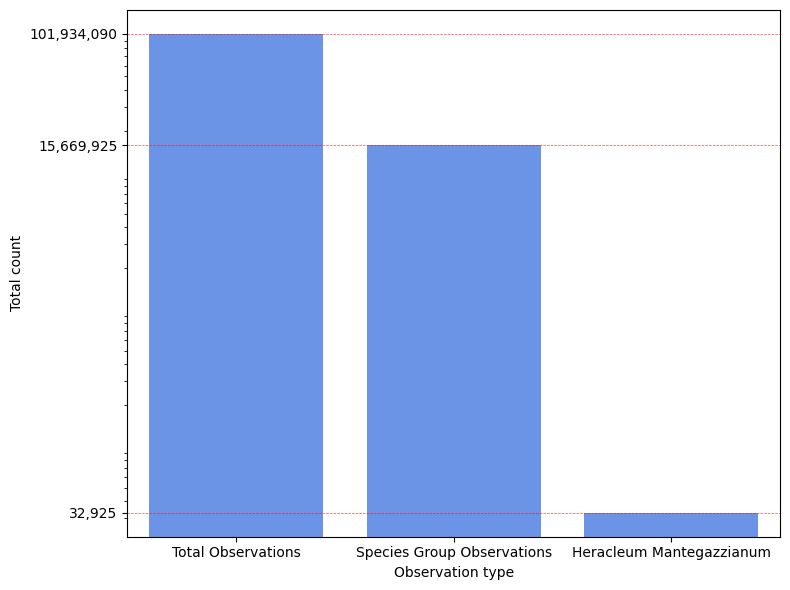

In [161]:
bias_df = df_merged[['total_observations', 'speciesgroup_observations', 'Heracleum mantegazzianum']]
bias_df = bias_df.sum().reset_index()
bias_df.columns = ['Observation type', 'Total count']

label_map = {
    'total_observations': 'Total Observations',
    'speciesgroup_observations': 'Species Group Observations',
    'Heracleum mantegazzianum': 'Heracleum Mantegazzianum'
}

bias_df['Observation type'] = bias_df['Observation type'].map(label_map)
totals = sorted(bias_df['Total count'].tolist())

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=bias_df, x='Observation type', y='Total count')
ax.set_yscale('log')
plt.yticks(totals, [f"{int(val):,}" for val in totals])
plt.grid(axis='y', linestyle='--', alpha=0.7, color='red')
plt.tight_layout()
plt.show()

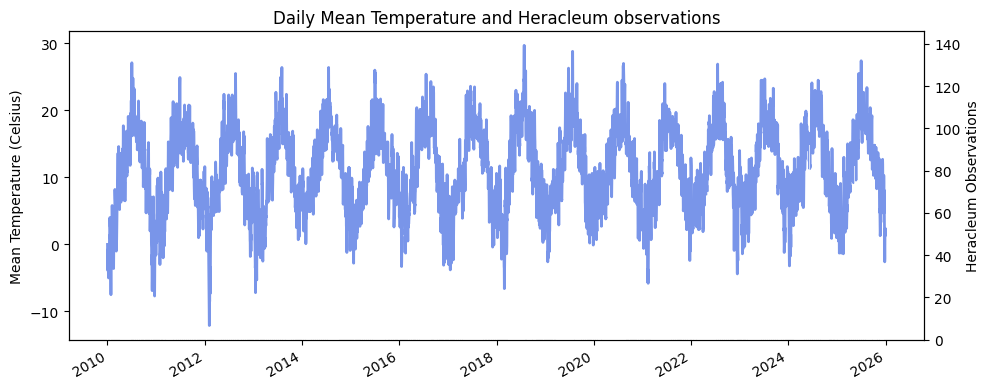

In [162]:
df_daily_counts = df_merged.groupby('eventDate').agg({
    'mean_temp_c': 'mean',
    'Heracleum mantegazzianum': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_daily_counts['eventDate'],
    df_daily_counts['mean_temp_c'],
    color='royalblue',
    linewidth=2,
    alpha=0.7
)

ax1.set_title('Daily Mean Temperature and Heracleum observations')
ax1.set_ylabel('Mean Temperature (Celsius)')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(
    df_daily_counts['eventDate'],
    df_daily_counts['Heracleum mantegazzianum'],
    color='yellow',
    alpha=0.7,
)

ax2.set_ylabel('Heracleum Observations')
ax2.grid(False)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

The Heracleum observations peak *significantly* when the mean temperature gets ***higher***, in the spring and summertime, and in the winters, when the temperature *decreases*, the observations also significantly ***decrease***.
(Ruben)

In [163]:
df_merged['cols'] = df_merged['decimalLongitude'].rank(method='dense').astype(np.int16)
df_merged['rows'] = df_merged['decimalLatitude'].rank(method='dense', ascending=False).astype(np.int16)
habitats = pd.read_csv('habitats_cbs_2022_rowscols.csv', engine='pyarrow')

df_merged = df_merged.merge(habitats[['rows', 'cols', 'main_habitat']], on=['rows', 'cols'], how='left')
df_merged = df_merged.rename(columns={'main_habitat': 'habitat_type'})


<Axes: xlabel='habitat_type', ylabel='Heracleum mantegazzianum'>

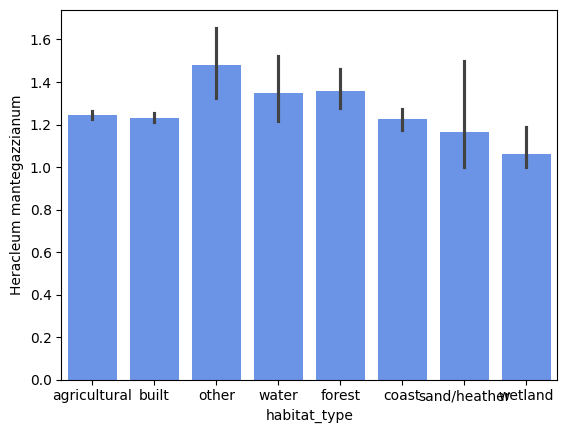

In [189]:
habitat_subset = df_merged[['habitat_type', 'Heracleum mantegazzianum']]

rows = habitat_subset[habitat_subset["Heracleum mantegazzianum"] == 0].index
habitat_subset.drop(rows, inplace=True)

habitat_subset.sample(100)
sns.barplot(habitat_subset, x='habitat_type', y='Heracleum mantegazzianum')